# 03. Floating Point Arithmetic

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. Describe the **IEEE 754** layout of a floating point number and pull a real double apart
   into its sign, exponent and mantissa.
2. Define **machine epsilon** precisely and compute it by experiment, not by lookup.
3. Explain the difference between **rounding** and **chopping** and the error bound each
   gives.
4. State the **standard model** $\mathrm{fl}(x) = x(1+\delta)$, $|\delta| \le u$, and verify
   it numerically.
5. Explain **overflow**, **underflow**, **subnormal** numbers, infinities and NaN.
6. Show why floating point addition is **not associative**, and predict when it loses the
   most.

## Prerequisites

Lessons 01 and 02. In particular Theorem 2.3, which told us that most decimal fractions have
no finite binary expansion. This lesson is about what a machine does with that fact when it
only has 64 bits.

---

## 1. The two limits

A real number needs, in general, infinitely many digits and an unbounded exponent. Hardware
gives you a fixed number of bits. Every consequence in this lesson comes from splitting those
bits between two competing needs:

| Need | Bits spent on it | What runs out |
|---|---|---|
| **Precision**, how many significant digits | the mantissa | accuracy, in the form of roundoff |
| **Range**, how large and small | the exponent | representable values, as overflow and underflow |

Fixed point arithmetic spends all its bits on precision and has terrible range. Floating point
splits them, which is why it is what hardware does.

## 2. The IEEE 754 layout

A normalized binary floating point number is written

$$x = \pm \, \underbrace{1.b_1 b_2 \cdots b_N}_{\text{significand}} \times 2^{\,p}.$$

The leading digit before the point is **always 1** for a normalized number, because if it
were 0 you would shift left and decrease the exponent. Since it is always 1, there is no need
to store it. That free bit is called the **hidden bit** or **implicit leading bit**, and it is
why double precision gets 53 bits of precision out of 52 stored bits.

The exponent is stored with a **bias** rather than a sign, so that comparing two positive
floats can be done by comparing their bit patterns as integers.

| Format | Total bits | Sign | Exponent | Stored mantissa | Precision | Bias |
|---|---|---|---|---|---|---|
| half | 16 | 1 | 5 | 10 | 11 bits | 15 |
| single | 32 | 1 | 8 | 23 | 24 bits | 127 |
| **double** | **64** | **1** | **11** | **52** | **53 bits** | **1023** |

Python's `float`, NumPy's `float64` and C's `double` are all the third row. Everything below
uses it unless stated otherwise.

The value stored is

$$x = (-1)^{s} \times \left(1 + \frac{m}{2^{52}}\right) \times 2^{\,e - 1023}$$

where $s$ is the sign bit, $m$ is the 52-bit mantissa field read as an integer, and $e$ is the
11-bit exponent field.

### Taking a number apart

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import floatingpoint as fp

for value in [1.0, 2.0, 9.0, 0.5, -3.25]:
    d = fp.decompose(value)
    print(f"{value:>7}  bits = {fp.format_bits(value)}")
    print(f"{'':>7}  sign {d['sign']:+d}   exponent {d['exponent']:+5d}   "
          f"significand {d['significand']:.10f}   [{d['kind']}]")
    # The reconstruction must be exact, not approximate.
    rebuilt = d["sign"] * d["significand"] * 2.0 ** d["exponent"]
    assert rebuilt == value, (value, rebuilt)
    print()

print("every value was reconstructed exactly from its three fields")

    1.0  bits = 0 01111111111 0000000000000000000000000000000000000000000000000000
         sign +1   exponent    +0   significand 1.0000000000   [normal]

    2.0  bits = 0 10000000000 0000000000000000000000000000000000000000000000000000
         sign +1   exponent    +1   significand 1.0000000000   [normal]

    9.0  bits = 0 10000000010 0010000000000000000000000000000000000000000000000000
         sign +1   exponent    +3   significand 1.1250000000   [normal]

    0.5  bits = 0 01111111110 0000000000000000000000000000000000000000000000000000
         sign +1   exponent    -1   significand 1.0000000000   [normal]

  -3.25  bits = 1 10000000000 1010000000000000000000000000000000000000000000000000
         sign -1   exponent    +1   significand 1.6250000000   [normal]

every value was reconstructed exactly from its three fields


Take $9.0$ as the worked example. In binary $9 = 1001_2 = 1.001_2 \times 2^3$. So the
significand is $1.125$, the exponent is $3$, and the stored exponent field should be
$3 + 1023 = 1026 = 10000000010_2$. That is exactly what the bit string above shows.

## 3. Machine epsilon

> **Definition 3.1 (Machine epsilon).** $\varepsilon_{\text{mach}}$ is the distance from
> $1$ to the **next larger** floating point number.

For IEEE double the mantissa has 52 stored bits, so the number after $1.000\ldots0_2 \times
2^0$ is $1.000\ldots1_2 \times 2^0$, which differs by $2^{-52}$.

$$\boxed{\varepsilon_{\text{mach}} = 2^{-52} \approx 2.22 \times 10^{-16}}$$

Do not look it up. Find it.

In [3]:
found = fp.machine_epsilon()

print(f"found by halving until 1 + eps/2 == 1 : {found:.17e}")
print(f"numpy.finfo(float).eps                : {np.finfo(float).eps:.17e}")
print(f"2**-52                                : {2.0**-52:.17e}")
assert found == np.finfo(float).eps == 2.0**-52
print("\nall three agree exactly")

print(f"\n1 + eps     != 1 ?  {1.0 + found != 1.0}")
print(f"1 + eps/2   == 1 ?  {1.0 + found/2 == 1.0}")
print(f"\nso eps really is the smallest thing you can add to 1 and see a change.")

found by halving until 1 + eps/2 == 1 : 2.22044604925031308e-16
numpy.finfo(float).eps                : 2.22044604925031308e-16
2**-52                                : 2.22044604925031308e-16

all three agree exactly

1 + eps     != 1 ?  True
1 + eps/2   == 1 ?  True

so eps really is the smallest thing you can add to 1 and see a change.


### Machine epsilon is not the smallest positive number

This confusion is extremely common, so let us kill it now.

In [4]:
print(f"machine epsilon        : {np.finfo(float).eps:.3e}")
print(f"smallest normal double : {np.finfo(float).tiny:.3e}")
print(f"smallest subnormal     : {5e-324:.3e}")
print()
print("machine epsilon is about RESOLUTION near 1, not about how small a number can be.")
print(f"eps / 1e300 = {np.finfo(float).eps / 1e300:.3e}, which is a perfectly fine double.")

machine epsilon        : 2.220e-16
smallest normal double : 2.225e-308
smallest subnormal     : 4.941e-324

machine epsilon is about RESOLUTION near 1, not about how small a number can be.
eps / 1e300 = 2.220e-316, which is a perfectly fine double.


Machine epsilon is a statement about **relative** spacing. It says nothing about absolute
magnitude.

## 4. Spacing: the number line is not uniform

Between consecutive powers of two, floating point numbers are evenly spaced. Cross a power of
two and the spacing doubles. So the grid is fine near zero and coarse far from it, and the
**relative** spacing stays roughly constant.

In [5]:
print(f"{'x':>12} {'ulp(x)':>14} {'ulp(x)/x':>12}")
print("-" * 42)
for x in [1e-8, 1.0, 2.0, 3.0, 1e3, 1e8, 1e16, 1e300]:
    print(f"{x:>12.0e} {fp.ulp(x):>14.3e} {fp.ulp(x)/x:>12.3e}")

print("\nabsolute spacing grows by 16 orders of magnitude across this table.")
print("relative spacing stays pinned between eps/2 and eps.")

           x         ulp(x)     ulp(x)/x
------------------------------------------
       1e-08      1.654e-24    1.654e-16
       1e+00      2.220e-16    2.220e-16
       2e+00      4.441e-16    2.220e-16
       3e+00      4.441e-16    1.480e-16
       1e+03      1.137e-13    1.137e-16
       1e+08      1.490e-08    1.490e-16
       1e+16      2.000e+00    2.000e-16
      1e+300     1.487e+284    1.487e-16

absolute spacing grows by 16 orders of magnitude across this table.
relative spacing stays pinned between eps/2 and eps.


Notice the last column: it never leaves the band $[\varepsilon/2, \varepsilon]$. **That is the
central promise of floating point.** You get a fixed number of significant digits, wherever
you are on the number line.

One consequence, which will matter in lesson 66 when we take small steps in a differential
equation:

In [6]:
big = 1e16
print(f"{big:.1f} + 1.0 == {big:.1f} ?  {big + 1.0 == big}")
print(f"spacing at 1e16 is {fp.ulp(big):.1f}, so adding 1 cannot change anything")
assert big + 1.0 == big
print()
print(f"but {big:.1f} + 4.0 != {big:.1f} ?  {big + 4.0 != big}")

10000000000000000.0 + 1.0 == 10000000000000000.0 ?  True
spacing at 1e16 is 2.0, so adding 1 cannot change anything

but 10000000000000000.0 + 4.0 != 10000000000000000.0 ?  True


At $10^{16}$ the gap between neighbouring doubles is $2$. Adding $1$ lands closer to where you
already were than to the next representable value, so it rounds straight back.

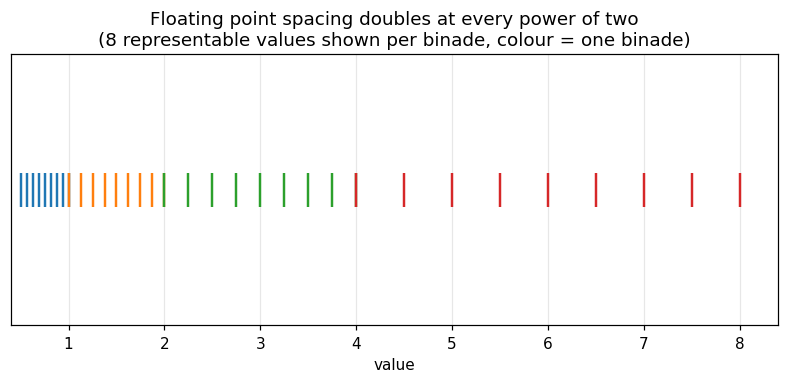

In [7]:
xs = np.array([0.5, 1.0, 2.0, 4.0, 8.0])
fig, ax = plt.subplots(figsize=(9, 3.2))
for lo, hi, colour in [(0.5, 1.0, "C0"), (1.0, 2.0, "C1"),
                       (2.0, 4.0, "C2"), (4.0, 8.0, "C3")]:
    grid = lo + np.arange(9) * (hi - lo) / 8
    ax.plot(grid, np.zeros_like(grid), "|", color=colour, ms=22, mew=1.6)
ax.set_yticks([])
ax.set_xlim(0.4, 8.4)
ax.set_xlabel("value")
ax.set_title("Floating point spacing doubles at every power of two\n"
             "(8 representable values shown per binade, colour = one binade)")
plt.show()

**What to take from this.** Each colour band holds the same *count* of representable numbers,
but covers twice the width of the one before. The grid stretches as you move right.

## 5. Rounding

Not every real number is on the grid, so the machine must pick a neighbour.

> **Definition 3.2 (Chopping and rounding).** **Chopping** (truncation) discards the bits
> beyond the mantissa. **Rounding** picks the nearest representable value, and on an exact tie
> picks the one whose last mantissa bit is 0. That tie rule is called **round to nearest, ties
> to even**, and it is the IEEE default.

The error bounds differ by a factor of two.

| Rule | Worst relative error | Bias over many operations |
|---|---|---|
| chopping | $\varepsilon_{\text{mach}} = 2^{-52}$ | always toward zero, so errors accumulate |
| round to nearest | $u = \varepsilon_{\text{mach}}/2 = 2^{-53}$ | none, errors tend to cancel |

The quantity $u = \varepsilon_{\text{mach}} / 2$ is the **unit roundoff**, and it is the
constant that appears in every error bound in this course.

Ties to even matters more than it looks. Rounding ties always up would bias every long sum
upward, and that bias grows with the number of operations. Ties to even makes the bias
average out.

In [8]:
print("round to nearest, ties to even, in the decimal analogue:")
for v in [0.5, 1.5, 2.5, 3.5, 4.5]:
    print(f"  round({v}) = {round(v)}   <- ties go to the even neighbour")
print("\nNote 0.5 -> 0 and 1.5 -> 2. Half the ties go down, half go up, so no drift.")

round to nearest, ties to even, in the decimal analogue:
  round(0.5) = 0   <- ties go to the even neighbour
  round(1.5) = 2   <- ties go to the even neighbour
  round(2.5) = 2   <- ties go to the even neighbour
  round(3.5) = 4   <- ties go to the even neighbour
  round(4.5) = 4   <- ties go to the even neighbour

Note 0.5 -> 0 and 1.5 -> 2. Half the ties go down, half go up, so no drift.


## 6. The standard model of floating point arithmetic

This is the single most useful fact in numerical analysis, and everything in lesson 06 rests
on it.

> **The standard model.** For any real $x$ in the normal range,
>
> $$\mathrm{fl}(x) = x(1 + \delta), \qquad |\delta| \le u = \tfrac{1}{2}\varepsilon_{\text{mach}}.$$
>
> Moreover, for each of the four arithmetic operations $\circ \in \{+, -, \times, \div\}$ and
> any two floating point numbers $a, b$ whose exact result is in range,
>
> $$\mathrm{fl}(a \circ b) = (a \circ b)(1 + \delta), \qquad |\delta| \le u.$$

In words: **every single operation is correct to within one rounding.** The hardware is not
sloppy. What goes wrong later comes from *accumulating* these small errors, or from
*amplifying* one of them, never from any individual operation being bad.

*(The formal statement of this model, and the name "standard model", are supplementary. The
underlying rounding facts are in both source books.)*

`nalib.floatingpoint` can simulate a machine with fewer mantissa bits, so we can test the
claim with numbers we could check by hand.

In [9]:
rng_local = np.random.default_rng(SEED)

print(f"{'mantissa bits':>14} {'unit roundoff u':>17} {'worst |delta| seen':>20} {'ok?':>5}")
print("-" * 62)
for bits in [4, 8, 16, 24, 52]:
    u = fp.simulated_unit_roundoff(bits)
    worst = 0.0
    for _ in range(20000):
        x = float(rng_local.standard_normal()) * 10.0 ** rng_local.integers(-6, 7)
        if x == 0.0:
            continue
        worst = max(worst, abs(fp.relative_rounding_error(x, bits)))
    print(f"{bits:>14} {u:>17.3e} {worst:>20.3e} {str(worst <= u):>5}")
    assert worst <= u, f"standard model violated at {bits} bits"

print("\nthe bound |delta| <= u held for every one of 100000 random values")

 mantissa bits   unit roundoff u   worst |delta| seen   ok?
--------------------------------------------------------------


             4         3.125e-02            3.029e-02  True


             8         1.953e-03            1.945e-03  True
            16         7.629e-06            7.546e-06  True


            24         2.980e-08            2.964e-08  True
            52         1.110e-16            0.000e+00  True

the bound |delta| <= u held for every one of 100000 random values


The bound holds, and it is close to tight: in every simulated row the worst observed error
sits just under $u$. That is what you want from a bound. A bound that is never approached is
not telling you much.

The last row reads exactly zero, and that is the right answer rather than a bug. Simulating
52 mantissa bits on a value that is *already* a double changes nothing, so the rounding error
is genuinely zero. It is a useful consistency check on the simulator itself.

## 7. Floating point addition, step by step

Addition is where the interesting damage happens, because the exponents must be **aligned**
before the mantissas can be added, and alignment shifts bits off the end.

The procedure is:

```text
FLOATING_ADD(a, b)
    1. compare exponents
    2. shift the mantissa of the smaller number right, increasing its exponent to match
       (bits shifted past the end of the mantissa are lost)
    3. add the two aligned mantissas
    4. renormalize so the leading bit is 1 again
    5. round the result to the available mantissa bits
```

Step 2 is where information disappears. If the exponents differ by more than the mantissa
width, the smaller number vanishes entirely.

In [10]:
a, b = 1.0, 2.0**-53

print(f"a           = {a}")
print(f"b           = 2^-53 = {b:.6e}")
print(f"exponent gap: {fp.decompose(a)['exponent'] - fp.decompose(b)['exponent']} "
      f"(mantissa holds only 52 bits)")
print()
print(f"a + b       = {a + b!r}")
print(f"a + b == a  ? {a + b == a}")
assert a + b == a
print("\nb was shifted entirely off the end of the mantissa during alignment.")
print("this is not a rounding of the sum; b never reached the adder at all.")

a           = 1.0
b           = 2^-53 = 1.110223e-16
exponent gap: 53 (mantissa holds only 52 bits)

a + b       = 1.0
a + b == a  ? True

b was shifted entirely off the end of the mantissa during alignment.
this is not a rounding of the sum; b never reached the adder at all.


### Addition is not associative

Because each addition rounds, the order you add in changes the answer.

In [11]:
x, y, z = 1.0, 2.0**-53, 2.0**-53

left = (x + y) + z
right = x + (y + z)

print(f"(1 + 2^-53) + 2^-53 = {left!r}")
print(f"1 + (2^-53 + 2^-53) = {right!r}")
print(f"equal? {left == right}")
assert left != right

print(f"\ndifference = {right - left:.3e}, which is exactly eps = {np.finfo(float).eps:.3e}")
assert right - left == np.finfo(float).eps

(1 + 2^-53) + 2^-53 = 1.0
1 + (2^-53 + 2^-53) = 1.0000000000000002
equal? False

difference = 2.220e-16, which is exactly eps = 2.220e-16


Grouped one way, each tiny value is lost during alignment. Grouped the other way, the two
tiny values combine into $2^{-52}$ first, which is large enough to survive.

> **Floating point addition is commutative but not associative.**

This is not a curiosity. It is why summing an array in a different order gives a different
answer, why parallel reductions are non-deterministic (lesson 96), and why the summation
algorithms in lesson 05 exist at all.

## 8. The edges of the range

### Overflow and infinity

In [12]:
big = np.finfo(float).max
print(f"largest finite double : {big:.6e}")
with np.errstate(over="ignore"):
    print(f"that value times 2    : {np.float64(big) * 2}")
print(f"1.0 / 0.0             : ", end="")
with np.errstate(divide="ignore"):
    print(np.float64(1.0) / np.float64(0.0))
print("\noverflow does not crash. it produces inf, and inf propagates.")

largest finite double : 1.797693e+308
that value times 2    : inf
1.0 / 0.0             : inf

overflow does not crash. it produces inf, and inf propagates.


### Underflow and subnormal numbers

Below the smallest normal number, IEEE does not jump straight to zero. It gives up the hidden
bit and lets the mantissa carry leading zeros. These are **subnormal** (or denormal) numbers.
They trade precision for the ability to represent smaller values, so the transition to zero is
gradual rather than abrupt.

In [13]:
tiny = np.finfo(float).tiny
print(f"smallest normal double     : {tiny:.6e}")
print(f"its bit pattern            : {fp.format_bits(tiny)}")
print()
sub = tiny / 2
d = fp.decompose(sub)
print(f"half of it                 : {sub:.6e}   [{d['kind']}]")
print(f"its bit pattern            : {fp.format_bits(sub)}")
print("   exponent field is all zeros, which is the subnormal flag")
print()
smallest = 5e-324
print(f"smallest subnormal         : {smallest:.6e}   "
      f"[{fp.decompose(smallest)['kind']}]")
print(f"half of THAT               : {smallest / 2}   <- flushed to zero")
assert smallest / 2 == 0.0

smallest normal double     : 2.225074e-308
its bit pattern            : 0 00000000001 0000000000000000000000000000000000000000000000000000

half of it                 : 1.112537e-308   [subnormal]
its bit pattern            : 0 00000000000 1000000000000000000000000000000000000000000000000000
   exponent field is all zeros, which is the subnormal flag

smallest subnormal         : 4.940656e-324   [subnormal]
half of THAT               : 0.0   <- flushed to zero


Subnormals buy range at the cost of precision. The smallest subnormal has only **one**
significant bit.

### Not a Number

In [14]:
with np.errstate(invalid="ignore", divide="ignore"):
    nan = np.float64(0.0) / np.float64(0.0)
    inf_minus_inf = np.float64(np.inf) - np.float64(np.inf)

print(f"0/0           = {nan}")
print(f"inf - inf     = {inf_minus_inf}")
print(f"nan == nan    ? {nan == nan}      <- NaN is not equal to itself, by design")
print(f"np.isnan(nan) ? {np.isnan(nan)}")
assert nan != nan
print("\nalways test for NaN with np.isnan, never with ==.")

0/0           = nan
inf - inf     = nan
nan == nan    ? False      <- NaN is not equal to itself, by design
np.isnan(nan) ? True

always test for NaN with np.isnan, never with ==.


## 9. Why 0.1 is stored the way it is

Lesson 02 proved that one tenth has no finite binary expansion. Now we can see exactly what
double precision does about it.

In [15]:
from fractions import Fraction
from nalib import numbersystems as ns

exact_tenth = Fraction(1, 10)
stored = Fraction(0.1)

print(f"1/10 in binary, first 60 bits : {ns.to_base(exact_tenth, 2, 60)}")
print(f"stored double, exactly        : {ns.to_base(stored, 2, 60)}")
print()
d = fp.decompose(0.1)
print(f"stored exponent    : {d['exponent']}")
print(f"stored significand : {d['significand']!r}")
print(f"stored mantissa    : {d['mantissa_bits']}")
print()
err = float(stored - exact_tenth)
print(f"absolute error : {err:.6e}")
print(f"relative error : {abs(err) / float(exact_tenth):.6e}")
print(f"unit roundoff  : {fp.UNIT_ROUNDOFF:.6e}")
assert abs(err) / float(exact_tenth) <= fp.UNIT_ROUNDOFF
print("\nthe relative error is within the unit roundoff, exactly as the model promises.")

1/10 in binary, first 60 bits : 0.000110011001100110011001100110011001100110011001100110011001...
stored double, exactly        : 0.0001100110011001100110011001100110011001100110011001101

stored exponent    : -4
stored significand : 1.6
stored mantissa    : 1001100110011001100110011001100110011001100110011010

absolute error : 5.551115e-18
relative error : 5.551115e-17
unit roundoff  : 1.110223e-16

the relative error is within the unit roundoff, exactly as the model promises.


The machine did the best possible thing: it stored the closest double to one tenth. The
standard model is satisfied. There is simply no exact answer available.

## 10. Simulating low precision

Reasoning about 53 bits is hard because you cannot see the bits. Reasoning about 4 bits is
easy. `round_to_precision` lets us work in a toy precision and watch the same phenomena at a
scale we can check by hand.

In [16]:
print("the number 1/3 rounded to different mantissa widths:\n")
print(f"{'bits':>6} {'value':>22} {'relative error':>17} {'bound u':>12}")
print("-" * 60)
third = 1.0 / 3.0
for bits in [2, 4, 8, 16, 24, 52]:
    v = fp.round_to_precision(third, bits)
    rel = abs(v - third) / third
    u = fp.simulated_unit_roundoff(bits)
    print(f"{bits:>6} {v:>22.17f} {rel:>17.3e} {u:>12.3e}")
    assert rel <= u
print("\nevery row respects its own unit roundoff. halving the bits doubles the error.")

the number 1/3 rounded to different mantissa widths:

  bits                  value    relative error      bound u
------------------------------------------------------------
     2    0.31250000000000000         6.250e-02    1.250e-01
     4    0.32812500000000000         1.562e-02    3.125e-02
     8    0.33300781250000000         9.766e-04    1.953e-03
    16    0.33333206176757812         3.815e-06    7.629e-06
    24    0.33333332836627960         1.490e-08    2.980e-08
    52    0.33333333333333331         0.000e+00    1.110e-16

every row respects its own unit roundoff. halving the bits doubles the error.


## 11. Complexity and cost

Floating point operations are not free, and they are not all the same price.

| Operation | Typical latency on modern hardware |
|---|---|
| add, subtract, multiply | a few cycles, fully pipelined |
| fused multiply-add (FMA) | same as a multiply, and rounds **once** instead of twice |
| divide | roughly 10 to 40 cycles, poorly pipelined |
| square root | similar to divide |

Two practical consequences that will come back repeatedly:

- **Replace division by multiplication when you can.** Computing `1.0/h` once and multiplying
  is faster than dividing in a loop. It also changes the rounding slightly, so it is a real
  numerical choice, not only a speed one.
- **FMA rounds once.** `a*b + c` computed as a single FMA is more accurate than computing
  `a*b`, rounding, then adding. This matters in dot products and is why compilers ask before
  contracting expressions.

## 12. Common mistakes

1. **Comparing with `==`.** Lesson 02 said it, this lesson explains why. Use a tolerance
   scaled to the size of the values involved.
2. **Thinking machine epsilon is the smallest positive number.** It is a *relative* spacing
   near 1. Section 3 shows the smallest positive double is over 300 orders of magnitude
   smaller.
3. **Assuming a sum is order independent.** Section 7. It is not, and the difference can be
   arbitrarily large for badly ordered data.
4. **Testing NaN with `==`.** NaN is not equal to itself. Use `np.isnan`.
5. **Trusting printed digits.** `print(x)` shows the shortest round-tripping form, not the
   stored value and not the correct digits.
6. **Blaming the hardware.** By the standard model each operation is correct to a rounding. If
   your answer is wrong in the third digit, the cause is accumulation or amplification, and
   lessons 05 and 06 will tell you which.

## 13. Exercises

**Level 1, conceptual**

1.1 Why is the leading bit of a normalized significand not stored?

1.2 State the difference between machine epsilon and the smallest positive normal double, and
give the value of each.

1.3 Why does IEEE round ties to even rather than always up?

**Level 2, mathematical**

2.1 Show that for double precision the relative spacing $\mathrm{ulp}(x)/|x|$ always lies in
$[2^{-53}, 2^{-52}]$ for normal $x$. Where in that range is it largest?

2.2 Derive the largest and smallest positive **normal** doubles from the format table in
section 2. Check your answers against `np.finfo(float).max` and `.tiny`.

2.3 Using the standard model, show that the computed value of $a(b+c)$ satisfies
$\mathrm{fl}(a(b+c)) = a(b+c)(1+\delta_1)(1+\delta_2)$ with each $|\delta_i| \le u$, and hence
that the total relative error is at most $2u + O(u^2)$.

**Level 3, computational**

3.1 Write `decompose` yourself using `struct` or bit masking, without looking at `nalib`.
Verify that `sign * significand * 2**exponent` reproduces the input exactly for 10000 random
doubles.

3.2 Write a function `nextafter_manual(x)` that returns the next double after `x`, by
incrementing the bit pattern as an integer. Check it against `math.nextafter`.

3.3 Implement `round_to_precision` yourself and confirm it agrees with `nalib`'s version for
mantissa widths 1 through 52 on random inputs.

**Level 4, experimental**

4.1 For $n$ from $10^3$ to $10^7$, sum an array of $n$ copies of $0.1$ and compare with
$0.1n$. Plot the relative error against $n$ on log-log axes. What growth rate do you see, and
does it match $O(nu)$?

4.2 Find, by search, a triple of doubles $a, b, c$ for which $(a+b)+c$ and $a+(b+c)$ differ by
as large a relative amount as you can manage. How large can you make it?

4.3 Compare `x*x` against `x**2` and against `np.square(x)` for a million random values. Are
they bit-identical? Should they be?

**Level 5, advanced**

5.1 The **Sterbenz lemma** says that if $a/2 \le b \le 2a$ then $a - b$ is computed
**exactly**, with no rounding at all. Prove it, then verify it experimentally over a large
random sample.

5.2 Implement `two_sum(a, b)`, which returns the rounded sum `s` **and** the exact rounding
error `e`, so that $a + b = s + e$ exactly. This is the primitive behind compensated
summation in lesson 05. Prove it is correct under the standard model.

5.3 Investigate `bfloat16`: 1 sign bit, 8 exponent bits, 7 mantissa bits. Compute its machine
epsilon and its range, and explain why deep learning hardware prefers it over IEEE half
precision which has 5 exponent and 10 mantissa bits. Lesson 93 returns to this.

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 14. Key takeaways

- Floating point splits a fixed bit budget between **precision** (mantissa) and **range**
  (exponent). Every limitation traces back to that split.
- IEEE double: 1 sign bit, 11 exponent bits, 52 stored mantissa bits, 53 bits of precision
  thanks to the hidden leading 1.
- $\varepsilon_{\text{mach}} = 2^{-52}$ is the gap from 1 to the next double. The **unit
  roundoff** $u = 2^{-53}$ is the bound on relative rounding error, and it is the constant in
  every later error estimate.
- **Standard model**: every individual operation is correct to within a factor $(1 + \delta)$
  with $|\delta| \le u$. Verified here on 100000 random values.
- Relative spacing is nearly constant, absolute spacing doubles at every power of two.
- Addition is **commutative but not associative**, because alignment discards bits.
- Overflow gives infinity, underflow degrades gracefully through subnormals, and invalid
  operations give NaN, which is not equal to itself.

## Where this goes next

We now know that every operation carries a relative error of at most $u$. Lesson 04 tracks
what happens when those errors **propagate** through a calculation. Lesson 05 covers the one
situation where a single operation destroys everything: **cancellation**. Lesson 06 then
separates the damage the problem forces on you from the damage your algorithm chose.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 0.3 (floating point formats, machine
representation, addition of floating point numbers) and Definition 0.1 for machine epsilon;
Gupta, Numerical Methods, sections 2.3.1, 2.3.2 and 2.3.5 (round-off error, overflow and
underflow, machine epsilon). The standard model stated in section 6, and the Sterbenz lemma
and two-sum in the exercises, are supplementary.*